In [7]:
!pip install tensorflow
!pip install pandas numpy scikit-learn matplotlib

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 3.4/351.2 MB 17.8 MB/s eta 0:00:20
   - -------------------------------------- 9.2/351.2 MB 21.9 MB/s eta 0:00:16
   - -------------------------------------- 14.4/351.2 MB 22.7 MB/s eta 0:00:15
   -- ------------------------------------- 22.0/351.2 MB 26.0 MB/s eta 0:00:13
   --- ------------------------------------ 29.6/351.2 MB 28.2 MB/s eta 0:00:12
   ---- ----------------------------------- 37.0/351.2 MB 29.3 MB/s eta 0:00:11
   ---- ----------------------------------- 41.9/351.2 MB 28.6 MB/s eta 0:00:11
   ----- ---------------------------------- 49.0/351.2 MB 29.3 MB/s eta 0:00:11
   ------ --------------------------------- 56.6/351.2 MB 29.9 MB/s eta 0:00:10
   ------- -------------------------------- 64.0/351.2 MB 30.4 MB/s eta 0:00:10
   -------- ------------------------------- 70.5/351.2 MB 30.3 MB/s eta 0:00:10
   -------- ------------------------------- 77.6/35

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


성공적으로 데이터를 로드했습니다.
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.2616 - val_loss: 0.0729
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0528 - val_loss: 0.0463
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0407 - val_loss: 0.0497
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0373 - val_loss: 0.0417
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0333 - val_loss: 0.0329
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0314 - val_loss: 0.0285
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0378 - val_loss: 0.0535
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0295 - val_loss: 0.0249
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0282 - val_loss: 0.0457
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0396 - val_loss: 0.0322
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0263 - val_loss: 0.0264
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58

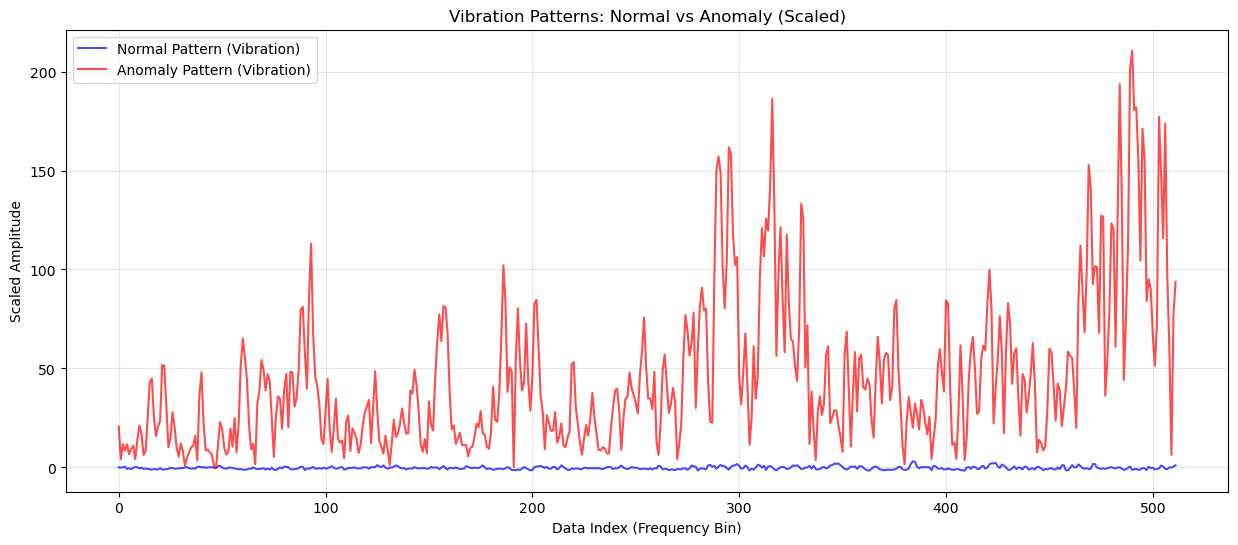

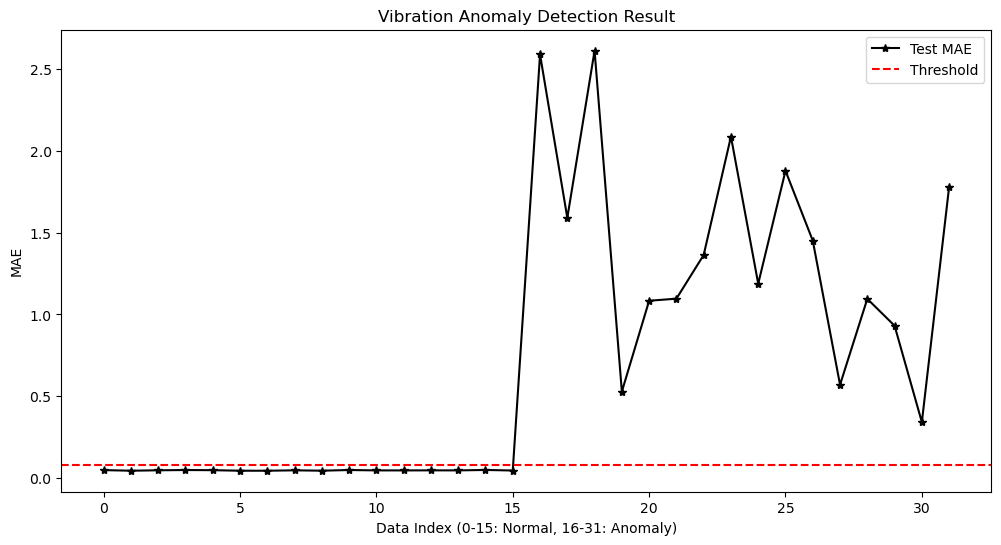

결정된 임계치: 0.0796985104010778


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Input, Conv1DTranspose
from tensorflow.keras.callbacks import EarlyStopping

path = 'data/' 

try:
    vib_normal = pd.read_csv(path + 'vibration_normal.csv')
    vib_anomaly = pd.read_csv(path + 'vibration_anomaly.csv')
    cur_normal = pd.read_csv(path + 'current_normal.csv')
    cur_anomaly = pd.read_csv(path + 'current_anomaly.csv')
    print("성공적으로 데이터를 로드했습니다.")
except FileNotFoundError:
    print("오류: 파일을 찾을 수 없습니다. 'data' 폴더와 파일명을 다시 확인하세요.")

vib_train = vib_normal.iloc[:1758, 1:].values 
vib_test = pd.concat([vib_normal.iloc[1758:, 1:], vib_anomaly.iloc[:, 1:]], ignore_index=True).values

cur_train = cur_normal.iloc[:8170, 1:].values
cur_test = pd.concat([cur_normal.iloc[8170:, 1:], cur_anomaly.iloc[:, 1:]], ignore_index=True).values

scaler = StandardScaler()
vib_train_scaled = scaler.fit_transform(vib_train)
vib_test_scaled = scaler.transform(vib_test)

cur_train_scaled = scaler.fit_transform(cur_train)
cur_test_scaled = scaler.transform(cur_test)

vib_train_final = vib_train_scaled.reshape(vib_train_scaled.shape[0], vib_train_scaled.shape[1], 1)
vib_test_final = vib_test_scaled.reshape(vib_test_scaled.shape[0], vib_test_scaled.shape[1], 1)

cur_train_final = cur_train_scaled.reshape(cur_train_scaled.shape[0], cur_train_scaled.shape[1], 1)
cur_test_final = cur_test_scaled.reshape(cur_test_scaled.shape[0], cur_test_scaled.shape[1], 1)

def build_model(input_data):
    model = Sequential([
        Input(shape=(input_data.shape[1], input_data.shape[2])),
        Conv1D(filters=64, kernel_size=input_data.shape[1]//64, padding='same', strides=2, activation='relu'),
        Conv1D(filters=32, kernel_size=input_data.shape[1]//64, padding='same', activation='relu'),
        Conv1DTranspose(filters=64, kernel_size=input_data.shape[1]//64, padding='same', strides=2, activation='relu'),
        Conv1DTranspose(filters=1, kernel_size=input_data.shape[1]//64, padding='same')
    ])
    return model

vib_model = build_model(vib_train_final)
vib_model.compile(optimizer='adam', loss='mae')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
vib_history = vib_model.fit(
    vib_train_final, vib_train_final, 
    epochs=50, 
    validation_split=0.2, 
    callbacks=[early_stopping],
    verbose=1
)

vib_train_pred = vib_model.predict(vib_train_final)
vib_train_mae = np.mean(np.abs(vib_train_pred - vib_train_final), axis=1)

threshold = np.mean(vib_train_mae) + 3*np.std(vib_train_mae)

vib_test_pred = vib_model.predict(vib_test_final)
vib_test_mae = np.mean(np.abs(vib_test_pred - vib_test_final), axis=1)

plt.figure(figsize=(15, 6))
plt.plot(vib_train_scaled[0], label='Normal Pattern (Vibration)', color='blue', alpha=0.7)
plt.plot(vib_test_scaled[-1], label='Anomaly Pattern (Vibration)', color='red', alpha=0.7)
plt.title('Vibration Patterns: Normal vs Anomaly (Scaled)')
plt.xlabel('Data Index (Frequency Bin)')
plt.ylabel('Scaled Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(vib_test_mae, marker='*', color='black', label='Test MAE')
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
plt.title('Vibration Anomaly Detection Result')
plt.xlabel('Data Index (0-15: Normal, 16-31: Anomaly)')
plt.ylabel('MAE')
plt.legend()
plt.show()

print(f"결정된 임계치: {threshold}")